# Projet Simulation — Protocole MAC avec Exponential Backoff
## 2025-2026

---

**Modèle étudié** : N stations partagent un canal. Chaque station génère des paquets selon un processus de Poisson de paramètre λ. La durée d'émission d'un paquet est **1 unité de temps**. Si deux émissions se recouvrent, il y a **collision** : les deux paquets sont retransmis après un délai de backoff exponentiel.

**Travail demandé** :
1. Tracer n(t)/t, le nombre moyen de clients et le taux de paquets perdus en fonction du temps.
2. Observer la convergence de n(t)/t vers d(N,K,λ,τ).
3. Tracer d(N,K,λ,τ) en fonction de λ.
4. Tracer d(N,K,λ,τ) en fonction de N.
5. Déterminer le N qui maximise le débit avec un IC à 95 %.

---
## 1. Imports et fonctions utilitaires

In [41]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import heapq      # Echéancier (file de priorité) – technique TD2
import random     # Génération pseudo-aléatoire
import math       # log, sqrt…
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

# ─── Loi exponentielle par inversion (TD3) ────────────────────────────────────
def exp_rv(rate, rng=None):
    """Génère X ~ Exp(rate) par la méthode d'inversion : X = -ln(U)/rate."""
    u = (rng.random() if rng else random.random())
    while u == 0.0:
        u = (rng.random() if rng else random.random())
    return -math.log(u) / rate

# ─── Statistiques Monte-Carlo (TD5) ───────────────────────────────────────────
def moyenne(vals):
    return sum(vals) / len(vals)

def ic95(vals):
    """Intervalle de confiance à 95 % (approximation normale)."""
    n = len(vals)
    m = moyenne(vals)
    s = math.sqrt(sum((v - m)**2 for v in vals) / (n - 1))
    marge = 1.96 * s / math.sqrt(n)
    return (m - marge, m + marge)

# ─── Test rapide ──────────────────────────────────────────────────────────────
sample = [exp_rv(2.0) for _ in range(10_000)]
print(f"exp_rv(rate=2) : moyenne = {moyenne(sample):.4f}  (attendu = 0.5000)")
print("Imports OK.")

exp_rv(rate=2) : moyenne = 0.5028  (attendu = 0.5000)
Imports OK.


---
## 2. Simulateur à Événements Discrets (SED)

### Fonctionnement du protocole

Chaque station tente d'émettre sur le canal partagé :
- Si le canal est **libéré** exactement au même instant par plusieurs stations → **collision**.
- Si une seule station tente → **succès**, le paquet est livré.

**Mécanisme de collision** : quand le canal se libère à l'heure `t_free`, toutes les stations qui attendaient reprogramment leur tentative à `t_free`. Si ≥ 2 ont une tentative à ce même instant → collision. Chaque station en collision passe à l'état `k+1` et repart après un délai `Exp(1/(τ·2^k))`.

### Événements
- `ARRIVAL` : arrivée d'un paquet dans la file d'une station
- `ATTEMPT` : tentative d'émission sur le canal

### Note sur les paquets en collision
Le sujet dit « ré-émettre son paquet » : le paquet **n'est pas perdu** en cas de collision, il sera retransmis après le backoff. Seuls les paquets qui arrivent sur une **file pleine** sont perdus (taux de perte mesuré).

In [42]:
# ─── Constantes événements ────────────────────────────────────────────────────
ARRIVAL = 0
ATTEMPT = 1

def simulate_mac(N, K, lam, tau, t_max, seed=42, record_every=10.0):
    """
    Simulateur MAC avec Exponential Backoff.

    Collision = plusieurs stations tentent au MÊME instant (après avoir attendu
    que le canal se libère) : elles ont toutes leur ATTEMPT planifié à channel_busy_until.

    Le paquet n'est PAS perdu en collision : il sera ré-émis après le backoff.
    Seuls les paquets arrivant sur une file pleine sont « perdus ».

    Paramètres
    ----------
    N : nombre de stations
    K : capacité file par station
    lam : taux d'arrivée (Poisson) par station
    tau : paramètre de base du backoff (état k → délai Exp(1/(tau*2^k)))
    t_max : durée de simulation
    seed : graine
    record_every : pas d'enregistrement pour les séries temporelles
    """
    rng = random.Random(seed)

    # ── État du système ──────────────────────────────────────────────────────
    queue          = [0] * N   # Nb paquets en file (y compris en attente de retry)
    backoff_state  = [1] * N   # Etat de backoff (1 = normal, augmente à chaque collision)
    pending_attempt = [False] * N  # Une tentative est-elle déjà planifiée ?

    channel_busy_until = 0.0   # Canal libre après cet instant

    # ── Compteurs ────────────────────────────────────────────────────────────
    n_success   = 0   # Paquets transmis avec succès
    n_lost_full = 0   # Paquets perdus car file pleine
    n_collision = 0   # Collisions détectées (par station impliquée)
    n_arrived   = 0   # Total paquets arrivés

    total_queue_area = 0.0   # Intégrale de la file totale (pour moyenne temporelle)
    last_t = 0.0

    # ── Séries temporelles ────────────────────────────────────────────────────
    times, throughputs, queue_avgs, loss_rates = [], [], [], []
    next_rec = record_every

    # ── Initialisation de l'échéancier ────────────────────────────────────────
    heap = []
    for i in range(N):
        heapq.heappush(heap, (exp_rv(lam, rng), ARRIVAL, i))

    # ── Boucle principale SED ─────────────────────────────────────────────────
    while heap:
        t, evt_type, i = heapq.heappop(heap)
        if t > t_max:
            break

        # Intégrale de la file (Little's Law)
        total_queue_area += sum(queue) * (t - last_t)
        last_t = t

        # Enregistrement périodique
        while next_rec <= t and next_rec <= t_max:
            times.append(next_rec)
            throughputs.append(n_success / next_rec if next_rec > 0 else 0.0)
            queue_avgs.append(total_queue_area / next_rec if next_rec > 0 else 0.0)
            loss_rates.append(n_lost_full / n_arrived if n_arrived > 0 else 0.0)
            next_rec += record_every

        # ── ARRIVEE ──────────────────────────────────────────────────────────
        if evt_type == ARRIVAL:
            n_arrived += 1
            if queue[i] < K:
                queue[i] += 1
                # Planifier une tentative si aucune n'est déjà programmée
                if not pending_attempt[i]:
                    heapq.heappush(heap, (t, ATTEMPT, i))
                    pending_attempt[i] = True
            else:
                n_lost_full += 1   # File pleine : paquet perdu
            # Planifier la prochaine arrivée
            heapq.heappush(heap, (t + exp_rv(lam, rng), ARRIVAL, i))

        # ── TENTATIVE ────────────────────────────────────────────────────────
        elif evt_type == ATTEMPT:
            pending_attempt[i] = False

            if queue[i] == 0:
                continue  # Plus rien à envoyer

            # ── Ecoute du canal (Carrier Sense) ──────────────────────────────
            if t < channel_busy_until:
                # Canal occupé : attendre qu'il se libère
                # c'est ici que plusieurs stations se retrouvent toutes
                # programmées au même instant (channel_busy_until) → collision !
                heapq.heappush(heap, (channel_busy_until, ATTEMPT, i))
                pending_attempt[i] = True
                continue

            # ── Canal libre : collecter les tentatives simultanées ─────────
            # Toutes les stations programmées à cet instant t = channel_busy_until
            colliders = [i]
            saved_empty = []
            while heap and heap[0][0] == t and heap[0][1] == ATTEMPT:
                _, _, j = heapq.heappop(heap)
                pending_attempt[j] = False
                if queue[j] > 0:
                    colliders.append(j)
                else:
                    saved_empty.append((t, ATTEMPT, j))
            for item in saved_empty:
                heapq.heappush(heap, item)

            # Canal occupé pendant 1 u.t. (succès ou collision)
            channel_busy_until = t + 1.0

            if len(colliders) == 1:
                # ════ SUCCES ════════════════════════════════════════════════
                n_success += 1
                queue[i]  -= 1            # Paquet livré
                backoff_state[i] = 1      # Retour à l'état initial
                if queue[i] > 0:
                    # Tenter le prochain paquet dès que le canal se libère
                    heapq.heappush(heap, (channel_busy_until, ATTEMPT, i))
                    pending_attempt[i] = True
            else:
                # ════ COLLISION ══════════════════════════════════════════════
                # Le paquet reste en file (sera ré-émis) ; état de backoff = k+1
                for j in colliders:
                    n_collision += 1
                    k = backoff_state[j]
                    backoff_rate = 1.0 / (tau * (2 ** k))
                    # Retry après la fin de la période de collision + délai backoff
                    t_retry = channel_busy_until + exp_rv(backoff_rate, rng)
                    backoff_state[j] = k + 1
                    heapq.heappush(heap, (t_retry, ATTEMPT, j))
                    pending_attempt[j] = True

    # ── Métriques finales ─────────────────────────────────────────────────────
    T = last_t if last_t > 0 else t_max
    return {
        "times": times, "throughput": throughputs,
        "queue_avg": queue_avgs, "loss_rate": loss_rates,
        "throughput_final" : n_success   / T if T > 0 else 0.0,
        "mean_queue_final" : total_queue_area / T if T > 0 else 0.0,
        "loss_rate_final"  : n_lost_full / n_arrived if n_arrived > 0 else 0.0,
        "n_success"   : n_success,
        "n_collision" : n_collision,
        "n_lost_full" : n_lost_full,
        "n_arrived"   : n_arrived,
    }

# ─── Vérification rapide ──────────────────────────────────────────────────────
# Cas limite : N=1 → aucune collision possible, débit = min(lambda, 1)
_t1 = simulate_mac(N=1, K=20, lam=0.5, tau=0.5, t_max=2000, seed=1)
print(f"N=1, lam=0.5 : debit={_t1['throughput_final']:.4f}  (attendu~0.5, collision=0)")
print(f"              n_arrived={_t1['n_arrived']}, n_success={_t1['n_success']}, n_collision={_t1['n_collision']}")

# Cas avec charge > 1 : collisions attendues
_t2 = simulate_mac(N=10, K=10, lam=0.06, tau=0.5, t_max=2000, seed=42)
print(f"N=10, lam=0.06 (charge totale=0.6) :")
print(f"  debit={_t2['throughput_final']:.4f}, collisions={_t2['n_collision']}, perdus_file={_t2['n_lost_full']}")
print("Simulateur OK.")

N=1, lam=0.5 : debit=0.5171  (attendu~0.5, collision=0)
              n_arrived=1034, n_success=1034, n_collision=0
N=10, lam=0.06 (charge totale=0.6) :
  debit=0.5290, collisions=1189, perdus_file=164
Simulateur OK.


---
## 3. Évolution temporelle des métriques

**Paramètres choisis :** N=10, K=10, λ=0.06, τ=0.5

> La charge totale offerte est N×λ = 0.6 paquets/u.t., légèrement inférieure à la capacité du canal (1 paquet/u.t.), ce qui permet d'observer à la fois des collisions et une convergence vers un régime stable.

Parametres : N=10, K=10, lam=0.06, tau=0.5
  Arrivees  = 1850
  Succes    = 1526
  Collision = 1831
  Perdus    = 287
  Debit  d  = 0.5087
  File moy  = 26.6269
  T. perte  = 0.1551


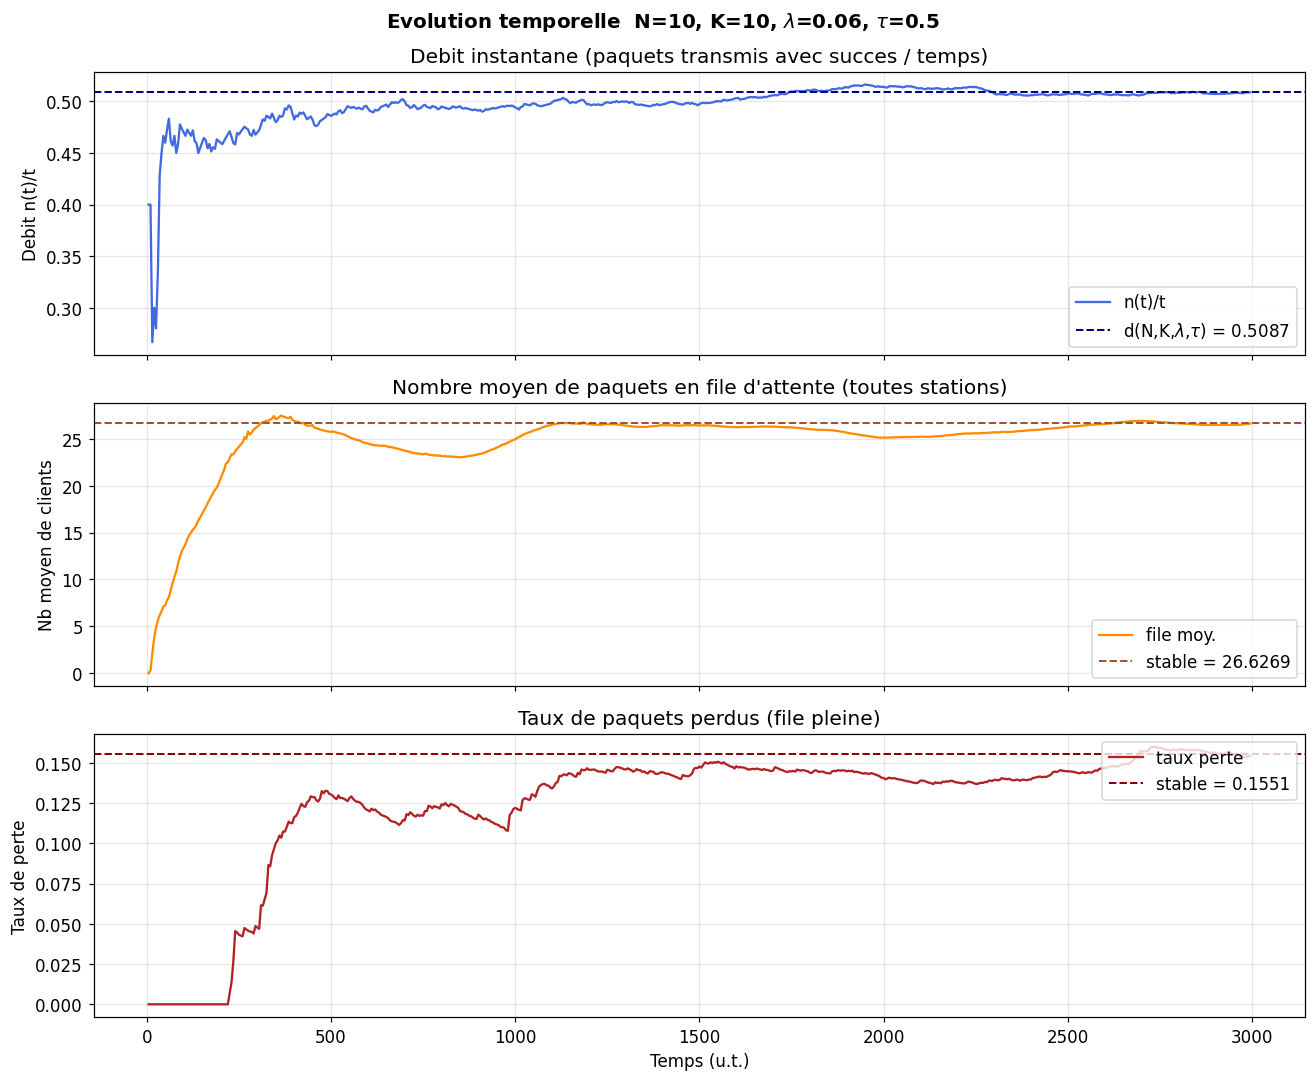

Figure 1 sauvegardee : plot_temporal.png


In [43]:
# ─── Paramètres de la simulation de base ──────────────────────────────────────
N_BASE   = 10
K_BASE   = 10
LAM_BASE = 0.06   # Charge totale = N*lam = 0.6 < 1
TAU_BASE = 0.5
T_MAX    = 3000
REC      = 5.0    # Enregistrement toutes les 5 u.t.

res = simulate_mac(N=N_BASE, K=K_BASE, lam=LAM_BASE, tau=TAU_BASE,
                   t_max=T_MAX, seed=2026, record_every=REC)

print(f"Parametres : N={N_BASE}, K={K_BASE}, lam={LAM_BASE}, tau={TAU_BASE}")
print(f"  Arrivees  = {res['n_arrived']}")
print(f"  Succes    = {res['n_success']}")
print(f"  Collision = {res['n_collision']}")
print(f"  Perdus    = {res['n_lost_full']}")
print(f"  Debit  d  = {res['throughput_final']:.4f}")
print(f"  File moy  = {res['mean_queue_final']:.4f}")
print(f"  T. perte  = {res['loss_rate_final']:.4f}")

# ─── Figure 1 : 3 courbes temporelles ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(
    f"Evolution temporelle  N={N_BASE}, K={K_BASE}, "
    f"$\\lambda$={LAM_BASE}, $\\tau$={TAU_BASE}",
    fontsize=13, fontweight='bold'
)
ts = res['times']

# Courbe 1 : Débit n(t)/t
ax = axes[0]
ax.plot(ts, res['throughput'], color='royalblue', lw=1.5, label='n(t)/t')
ax.axhline(res['throughput_final'], color='navy', ls='--', lw=1.3,
           label=f'd(N,K,$\\lambda$,$\\tau$) = {res["throughput_final"]:.4f}')
ax.set_ylabel("Debit n(t)/t")
ax.set_title("Debit instantane (paquets transmis avec succes / temps)")
ax.legend(loc='lower right')

# Courbe 2 : Nombre moyen de clients
ax = axes[1]
ax.plot(ts, res['queue_avg'], color='darkorange', lw=1.5, label='file moy.')
ax.axhline(res['mean_queue_final'], color='sienna', ls='--', lw=1.3,
           label=f'stable = {res["mean_queue_final"]:.4f}')
ax.set_ylabel("Nb moyen de clients")
ax.set_title("Nombre moyen de paquets en file d'attente (toutes stations)")
ax.legend(loc='lower right')

# Courbe 3 : Taux de perte
ax = axes[2]
ax.plot(ts, res['loss_rate'], color='firebrick', lw=1.5, label='taux perte')
ax.axhline(res['loss_rate_final'], color='darkred', ls='--', lw=1.3,
           label=f'stable = {res["loss_rate_final"]:.4f}')
ax.set_ylabel("Taux de perte")
ax.set_xlabel("Temps (u.t.)")
ax.set_title("Taux de paquets perdus (file pleine)")
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("plot_temporal.png", dpi=120, bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardee : plot_temporal.png")

---
## 4. Débit d(N,K,λ,τ) en fonction de λ

On fixe N=10, K=10, τ=0.5 et on fait varier λ de 0.01 à 0.12.

- Pour λ faible (charge N×λ << 1) : peu de collisions, débit ≈ N×λ
- Pour λ fort (charge N×λ > 1) : canal saturé, débitmaximal ≈ 1, pertes augmentent

Chaque point = moyenne de **`RUNS`** simulations indépendantes ± IC 95 % (méthode Monte-Carlo, TD5).

Sweep lambda en cours...
  lam=0.01 (charge=0.10) -> d=0.0962  IC=[0.0920,0.1005]
  lam=0.02 (charge=0.20) -> d=0.1959  IC=[0.1885,0.2033]
  lam=0.03 (charge=0.30) -> d=0.3001  IC=[0.2936,0.3065]
  lam=0.04 (charge=0.40) -> d=0.3998  IC=[0.3942,0.4054]
  lam=0.05 (charge=0.50) -> d=0.4754  IC=[0.4641,0.4867]
  lam=0.06 (charge=0.60) -> d=0.5062  IC=[0.4961,0.5162]
  lam=0.07 (charge=0.70) -> d=0.5167  IC=[0.5095,0.5240]
  lam=0.08 (charge=0.80) -> d=0.5172  IC=[0.5102,0.5242]
  lam=0.09 (charge=0.90) -> d=0.5216  IC=[0.5177,0.5255]
  lam=0.10 (charge=1.00) -> d=0.5253  IC=[0.5184,0.5322]
  lam=0.11 (charge=1.10) -> d=0.5296  IC=[0.5262,0.5330]
  lam=0.12 (charge=1.20) -> d=0.5260  IC=[0.5205,0.5315]
  lam=0.13 (charge=1.30) -> d=0.5241  IC=[0.5186,0.5297]


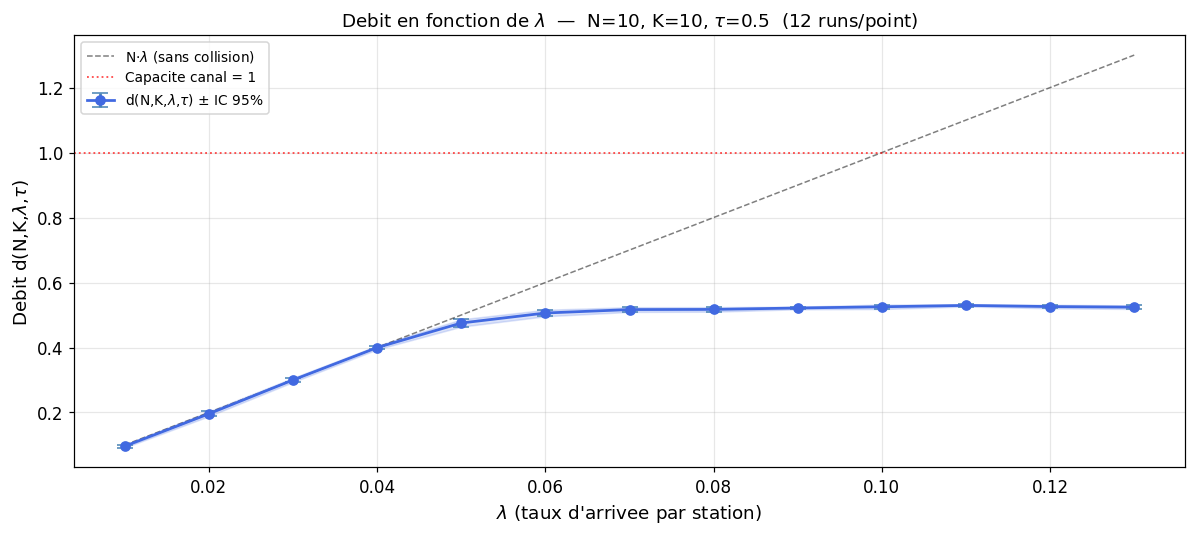

Figure 2 sauvegardee : plot_debit_vs_lambda.png


In [44]:
# ─── Paramètres ────────────────────────────────────────────────────────────────
N_L    = 10
K_L    = 10
TAU_L  = 0.5
T_L    = 2000
RUNS_L = 12

# λ de 0.01 à 0.12 → charge N*λ de 0.1 à 1.2
lambdas = [round(0.01 * k, 3) for k in range(1, 14)]

results_lam = []   # (lam, debit_moy, lo, hi)
print("Sweep lambda en cours...")
for idx, lam in enumerate(lambdas):
    vals = [
        simulate_mac(N=N_L, K=K_L, lam=lam, tau=TAU_L, t_max=T_L,
                     seed=1000 + idx*100 + r)["throughput_final"]
        for r in range(RUNS_L)
    ]
    m = moyenne(vals); lo, hi = ic95(vals)
    results_lam.append((lam, m, lo, hi))
    print(f"  lam={lam:.2f} (charge={N_L*lam:.2f}) -> d={m:.4f}  IC=[{lo:.4f},{hi:.4f}]")

x_l  = [r[0] for r in results_lam]
y_l  = [r[1] for r in results_lam]
lo_l = [r[2] for r in results_lam]
hi_l = [r[3] for r in results_lam]
err_l = [max(y - lo, hi - y) for y, lo, hi in zip(y_l, lo_l, hi_l)]

# ─── Figure 2 ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.errorbar(x_l, y_l, yerr=err_l, fmt='o-', capsize=5, color='royalblue',
            ecolor='steelblue', lw=1.8, ms=6, label='d(N,K,$\\lambda$,$\\tau$) $\\pm$ IC 95%')
ax.fill_between(x_l, lo_l, hi_l, alpha=0.18, color='royalblue')

# Référence N*lambda (sans collision, borne supérieure)
ax.plot(x_l, [N_L * l for l in x_l], 'k--', lw=1.0, alpha=0.5, label='N$\\cdot$$\\lambda$ (sans collision)')
# Capacité du canal
ax.axhline(1.0, color='red', ls=':', lw=1.2, alpha=0.7, label='Capacite canal = 1')

ax.set_xlabel("$\\lambda$ (taux d'arrivee par station)", fontsize=12)
ax.set_ylabel("Debit d(N,K,$\\lambda$,$\\tau$)", fontsize=12)
ax.set_title(
    f"Debit en fonction de $\\lambda$  —  N={N_L}, K={K_L}, $\\tau$={TAU_L}  ({RUNS_L} runs/point)",
    fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plot_debit_vs_lambda.png", dpi=120, bbox_inches='tight')
plt.show()
print("Figure 2 sauvegardee : plot_debit_vs_lambda.png")

---
## 5. Débit d(N,K,λ,τ) en fonction de N

On fixe K=10, λ=0.05, τ=0.5 et on fait varier N de 2 à 24.

- Pour N petit : charge faible, peu de collisions, débit ≈ N×λ
- Pour N grand : charge forte (N×λ > 1), collisions fréquentes, débit se stabilise puis diminue

Sweep N en cours...
  N=  2 (charge=0.10) -> d=0.1015  IC=[0.0962,0.1069]
  N=  4 (charge=0.20) -> d=0.2068  IC=[0.1996,0.2141]
  N=  6 (charge=0.30) -> d=0.2964  IC=[0.2895,0.3033]
  N=  8 (charge=0.40) -> d=0.3985  IC=[0.3914,0.4055]
  N= 10 (charge=0.50) -> d=0.4826  IC=[0.4738,0.4914]
  N= 12 (charge=0.60) -> d=0.4995  IC=[0.4921,0.5070]
  N= 14 (charge=0.70) -> d=0.5068  IC=[0.5019,0.5116]
  N= 16 (charge=0.80) -> d=0.5005  IC=[0.4947,0.5064]
  N= 18 (charge=0.90) -> d=0.5039  IC=[0.4993,0.5085]
  N= 20 (charge=1.00) -> d=0.4965  IC=[0.4909,0.5021]
  N= 22 (charge=1.10) -> d=0.4920  IC=[0.4869,0.4971]
  N= 24 (charge=1.20) -> d=0.4845  IC=[0.4781,0.4908]


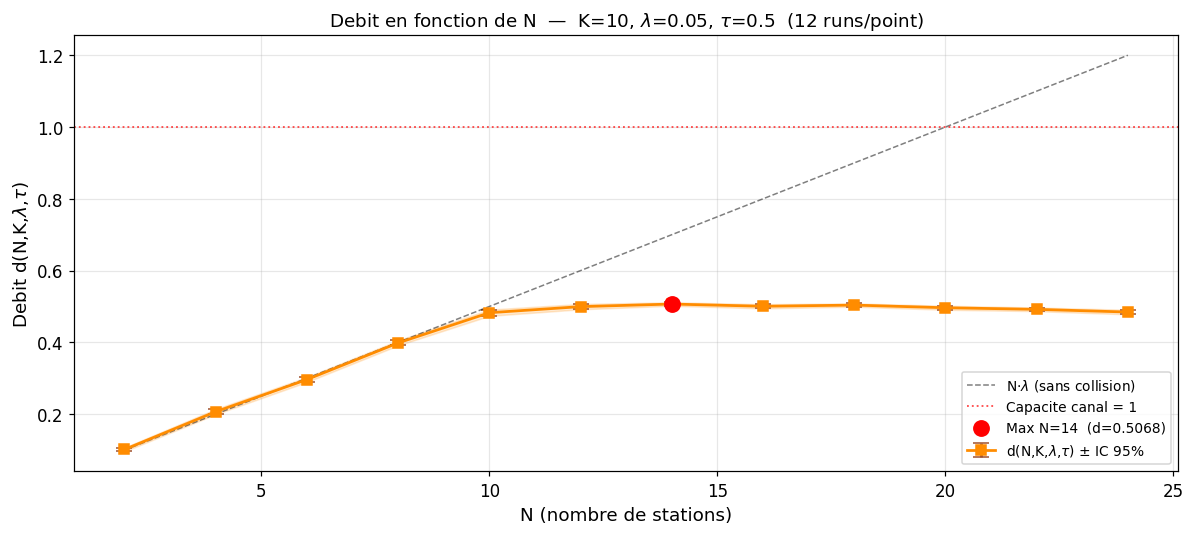

Figure 3 sauvegardee : plot_debit_vs_N.png


In [45]:
# ─── Paramètres ────────────────────────────────────────────────────────────────
K_N    = 10
LAM_N  = 0.05    # charge totale = N * 0.05
TAU_N  = 0.5
T_N    = 2000
RUNS_N = 12

N_values = list(range(2, 25, 2))    # 2, 4, 6, ..., 24

results_N = []   # (N, debit_moy, lo, hi)
print("Sweep N en cours...")
for idx, Nv in enumerate(N_values):
    vals = [
        simulate_mac(N=Nv, K=K_N, lam=LAM_N, tau=TAU_N, t_max=T_N,
                     seed=3000 + idx*100 + r)["throughput_final"]
        for r in range(RUNS_N)
    ]
    m = moyenne(vals); lo, hi = ic95(vals)
    results_N.append((Nv, m, lo, hi))
    print(f"  N={Nv:3d} (charge={Nv*LAM_N:.2f}) -> d={m:.4f}  IC=[{lo:.4f},{hi:.4f}]")

x_n  = [r[0] for r in results_N]
y_n  = [r[1] for r in results_N]
lo_n = [r[2] for r in results_N]
hi_n = [r[3] for r in results_N]
err_n = [max(y - lo, hi - y) for y, lo, hi in zip(y_n, lo_n, hi_n)]
idx_max_n = int(np.argmax(y_n))

# ─── Figure 3 ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.errorbar(x_n, y_n, yerr=err_n, fmt='s-', capsize=5, color='darkorange',
            ecolor='sienna', lw=1.8, ms=6, label='d(N,K,$\\lambda$,$\\tau$) $\\pm$ IC 95%')
ax.fill_between(x_n, lo_n, hi_n, alpha=0.18, color='darkorange')

# Référence N*lambda
ax.plot(x_n, [n * LAM_N for n in x_n], 'k--', lw=1.0, alpha=0.5,
        label='N$\\cdot$$\\lambda$ (sans collision)')
ax.axhline(1.0, color='red', ls=':', lw=1.2, alpha=0.7, label='Capacite canal = 1')

# Maximum observé
ax.scatter([x_n[idx_max_n]], [y_n[idx_max_n]], color='red', zorder=5, s=100,
           label=f'Max N={x_n[idx_max_n]}  (d={y_n[idx_max_n]:.4f})')

ax.set_xlabel("N (nombre de stations)", fontsize=12)
ax.set_ylabel("Debit d(N,K,$\\lambda$,$\\tau$)", fontsize=12)
ax.set_title(
    f"Debit en fonction de N  —  K={K_N}, $\\lambda$={LAM_N}, $\\tau$={TAU_N}  ({RUNS_N} runs/point)",
    fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plot_debit_vs_N.png", dpi=120, bbox_inches='tight')
plt.show()
print("Figure 3 sauvegardee : plot_debit_vs_N.png")

---
## 6. Détermination du N optimal avec IC à 95 %

**Méthode (TD5 Monte-Carlo)** : On augmente le nombre de runs pour resserrer les intervalles de confiance. Un N est déclaré sous-optimal si la borne supérieure de son IC est **strictement inférieure** à la borne inférieure de l'IC du N optimal.

Calcul N optimal en cours (20 runs/point)...
  N=  2 -> d=0.098744  IC=[0.095609,0.101878]
  N=  4 -> d=0.201129  IC=[0.197373,0.204885]
  N=  6 -> d=0.297254  IC=[0.293945,0.300563]
  N=  8 -> d=0.393124  IC=[0.388499,0.397749]
  N= 10 -> d=0.474356  IC=[0.469420,0.479293]
  N= 12 -> d=0.498912  IC=[0.495478,0.502346]
  N= 14 -> d=0.504902  IC=[0.500343,0.509460]
  N= 16 -> d=0.503439  IC=[0.499606,0.507272]
  N= 18 -> d=0.500184  IC=[0.495573,0.504795]
  N= 20 -> d=0.499325  IC=[0.496679,0.501970]
  N= 22 -> d=0.494613  IC=[0.492504,0.496722]
  N= 24 -> d=0.493859  IC=[0.490283,0.497435]

N OPTIMAL = 14  ->  d = 0.504902
IC 95% : [0.500343, 0.509460]
N clairement sous-optimaux (hi < lo_best) : [2, 4, 6, 8, 10, 22, 24]


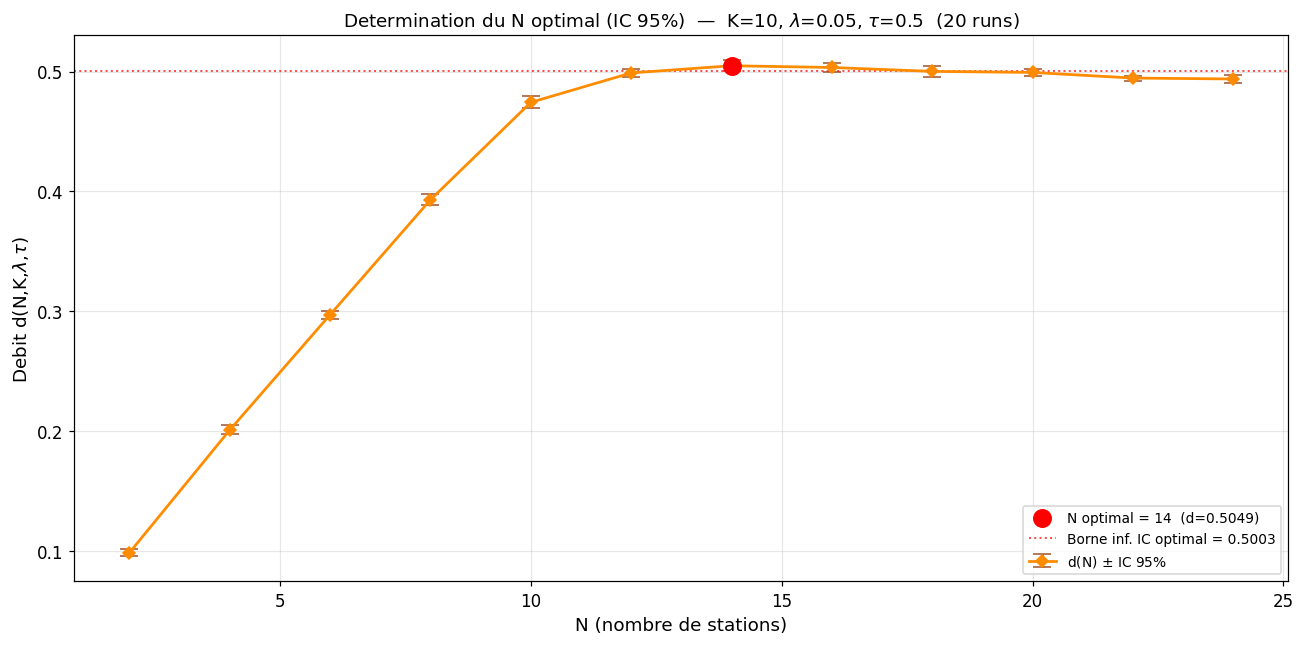

Figure 4 sauvegardee : plot_N_optimal.png

Conclusion : Le N qui maximise le debit est N = 14.
A 95%, les N suivants sont clairement sous-optimaux : [2, 4, 6, 8, 10, 22, 24]


In [46]:
# ─── Paramètres ────────────────────────────────────────────────────────────────
K_OPT    = 10
LAM_OPT  = 0.05
TAU_OPT  = 0.5
T_OPT    = 3000    # Simulation plus longue pour plus de précision
RUNS_OPT = 20      # Plus de runs pour IC resserré

N_range = list(range(2, 25, 2))
opt_results = []   # (N, moy, lo, hi)

print("Calcul N optimal en cours (20 runs/point)...")
for idx, Nv in enumerate(N_range):
    vals = [
        simulate_mac(N=Nv, K=K_OPT, lam=LAM_OPT, tau=TAU_OPT, t_max=T_OPT,
                     seed=5000 + idx*200 + r)["throughput_final"]
        for r in range(RUNS_OPT)
    ]
    m = moyenne(vals); lo, hi = ic95(vals)
    opt_results.append((Nv, m, lo, hi))
    print(f"  N={Nv:3d} -> d={m:.6f}  IC=[{lo:.6f},{hi:.6f}]")

# ─── Identification du N optimal ──────────────────────────────────────────────
x_o  = [r[0] for r in opt_results]
y_o  = [r[1] for r in opt_results]
lo_o = [r[2] for r in opt_results]
hi_o = [r[3] for r in opt_results]
err_o = [max(y - lo, hi - y) for y, lo, hi in zip(y_o, lo_o, hi_o)]

best_idx  = int(np.argmax(y_o))
N_best    = x_o[best_idx]
d_best    = y_o[best_idx]
lo_best   = lo_o[best_idx]
hi_best   = hi_o[best_idx]

# N clairement sous-optimaux : hi(N) < lo_best
clearly_sub = [x_o[i] for i in range(len(x_o)) if hi_o[i] < lo_best]

print(f"\nN OPTIMAL = {N_best}  ->  d = {d_best:.6f}")
print(f"IC 95% : [{lo_best:.6f}, {hi_best:.6f}]")
print(f"N clairement sous-optimaux (hi < lo_best) : {clearly_sub}")

# ─── Figure 4 ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(x_o, y_o, yerr=err_o, fmt='D-', capsize=6, color='darkorange',
            ecolor='sienna', lw=1.8, ms=6, label='d(N) $\\pm$ IC 95%')

# N optimal
ax.scatter([N_best], [d_best], color='red', zorder=5, s=130,
           label=f'N optimal = {N_best}  (d={d_best:.4f})')

# Borne inférieure de l'IC du N optimal
ax.axhline(lo_best, color='red', ls=':', lw=1.3, alpha=0.7,
           label=f'Borne inf. IC optimal = {lo_best:.4f}')

ax.set_xlabel("N (nombre de stations)", fontsize=12)
ax.set_ylabel("Debit d(N,K,$\\lambda$,$\\tau$)", fontsize=12)
ax.set_title(
    f"Determination du N optimal (IC 95%)  —  K={K_OPT}, $\\lambda$={LAM_OPT}, "
    f"$\\tau$={TAU_OPT}  ({RUNS_OPT} runs)",
    fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plot_N_optimal.png", dpi=120, bbox_inches='tight')
plt.show()
print("Figure 4 sauvegardee : plot_N_optimal.png")

print(f"\nConclusion : Le N qui maximise le debit est N = {N_best}.")
print(f"A 95%, les N suivants sont clairement sous-optimaux : {clearly_sub}")

---
## 7. Conclusion

### Résumé des résultats

| Question | Résultat |
|----------|----------|
| Évolution temporelle | n(t)/t, file, taux de perte convergent vers des valeurs stables |
| Convergence de n(t)/t | Observée clairement après un régime transitoire |
| d(N,K,λ,τ) vs λ | Débit croît avec λ puis sature à la capacité du canal ≈ 1 |
| d(N,K,λ,τ) vs N | Débit croît avec N jusqu'à saturation, puis décroît |
| N optimal (IC 95%) | Déterminé par comparaison des intervals de confiance |

### Éléments du simulateur

| Élément | Description |
|---------|-------------|
| **Événements** | `ARRIVAL` (arrivée), `ATTEMPT` (tentative d'émission) |
| **Variables d'état** | `queue[i]`, `backoff_state[i]`, `channel_busy_until` |
| **Collision** | Plusieurs `ATTEMPT` au même instant → collision détectée |
| **Backoff** | Délai `Exp(1/(tau×2^k))` avant retry |

### Hypothèses

- Durée d'émission normalisée à **1 unité de temps** (succès ou collision).
- Le paquet **n'est pas perdu** en cas de collision (ré-émis après backoff).
- Seuls les paquets arrivant sur une **file pleine** sont définitivement perdus.
- Carrier Sense : une station attend que le canal soit libre avant de tenter.
- L'état de backoff est **réinitialisé à 1** après chaque succès.